# Задание 5

## Кластеризация

### *Цель работы:* научиться производить кластерный анализ данных с использованием метода К-средних.
**Основные задачи:**

• изучение инструментария Python для реализации алгоритмов кластерного анализа;

• изучение принципов определения оптимального количества кластеров в методах кластерного анализа;

• освоение метода К-средних;

• изучение методов визуализации модели и оценки ее корректности.

Проанализируем датасет **wholesale.csv**.  Набор данных содержит информацию о клиентах оптового дистрибьютора. Он включает годовые расходы в денежных единицах на различные категории продуктов.

**Атрибуты:**

• *Fresh* – годовые расходы (ден.е.) на свежие продукты (непрерывно);

• *Milk* – годовые расходы (ден.е.) на молочные продукты (непрерывно);

• *Grocery* – годовые расходы (ден.е.) на бакалейные товары (непрерывно);

• *Frozen* – годовые расходы (ден.е.) на замороженные продукты (непрерывно)

• *Detergents_paper* – годовые расходы (ден.е.) на моющие средства и бумажные изделия (непрерывно)

• *Delicatessen* – годовые расходы (ден.е.) на деликатесы и продукты (непрерывно);

• *Channel* – канал сбыта клиентов – Horeca (гостиница/ресторан/кафе) или розничный канал (номинально)

• *Region* – регион сбыта клиентов – Лиснон, Порту или другой (номинально)

# 1. Импортируйте необходимые библиотеки

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# 2. Импортируйте набор данных из файла blood.сsv и поместите его в объект DataFrame

In [2]:
df = pd.read_csv("wholesale.csv")

# 3. Выведите данные

In [6]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# 4. Получим информацию о датасете

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


# 5. Проверим наличие пропущенных значений и выбросов

Проверим датасе на пропущенные значения:

In [8]:
print(df.isnull().sum())

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


Нулевые значения в датасете отсутствуют. 

# 6. Применяем операцию нормализации для численной устойчивости

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler = StandardScaler()
scaler

StandardScaler()

In [12]:
y = df['Channel']
X = df.drop('Channel', axis=1)

X.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3,12669,9656,7561,214,2674,1338
1,3,7057,9810,9568,1762,3293,1776
2,3,6353,8808,7684,2405,3516,7844
3,3,13265,1196,4221,6404,507,1788
4,3,22615,5410,7198,3915,1777,5185


In [13]:
y = df['Region']
X = df.drop('Region', axis=1)

X.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# 7. Приведем данные к единому масштабу

In [17]:
X = scaler.fit_transform(df)
X[:5]

array([[ 1.44865163,  0.59066829,  0.05293319,  0.52356777, -0.04111489,
        -0.58936716, -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197,  0.54445767,  0.17031835,
        -0.27013618,  0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926,  0.40853771, -0.0281571 ,
        -0.13753572,  0.13323164,  2.24329255],
       [-0.69029709,  0.59066829,  0.10011141, -0.62401993, -0.3929769 ,
         0.6871443 , -0.49858822,  0.09341105],
       [ 1.44865163,  0.59066829,  0.84023948, -0.05239645, -0.07935618,
         0.17385884, -0.23191782,  1.29934689]])

# 8. Определеяем оптимальное количество кластером с помощью метода локтя.

E:\Users\sine\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\Users\sine\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\Users\sine\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
E:\Users\sine\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

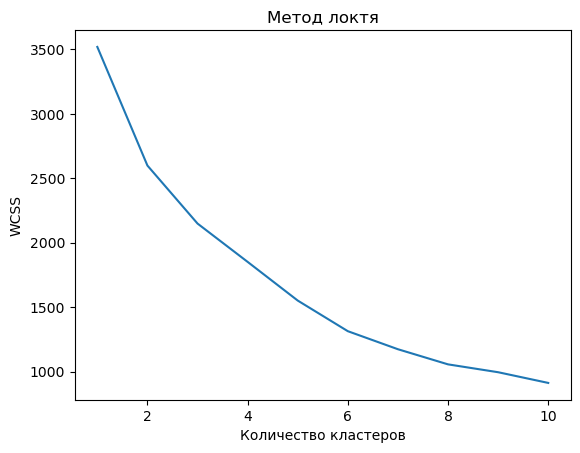

In [20]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

По графику видно, что кластеров 6.

# 9. Обучаем модель кластеризации

In [30]:
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
kmeans.fit(X)

E:\Users\sine\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=6, random_state=42)

# 10. Предсказываем кластеры и визуализируем результаты

In [31]:
clusters = kmeans.predict(X)

df['cluster'] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,0


# 11. Визуализация результатов

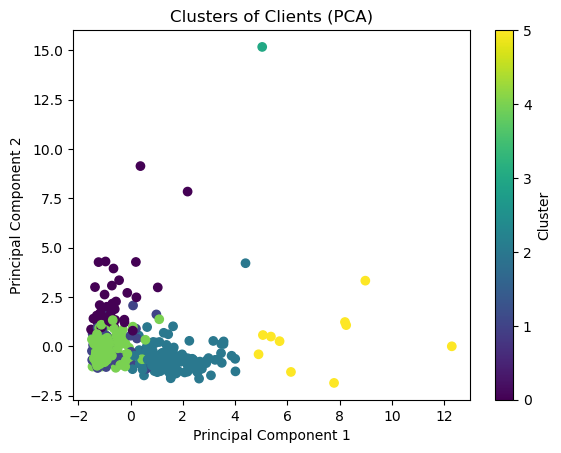

In [27]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

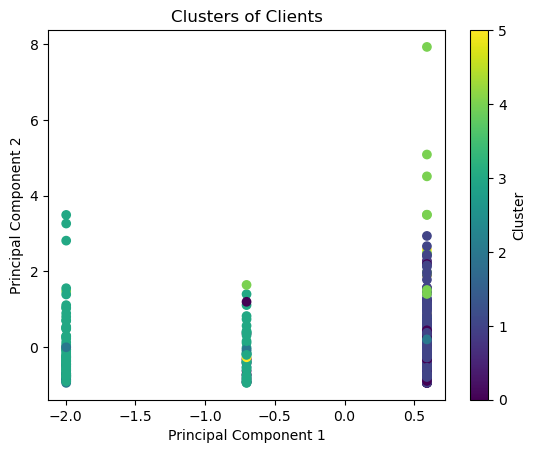

In [38]:
plt.scatter(X[:, 1], X[:, 2], c=clusters, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

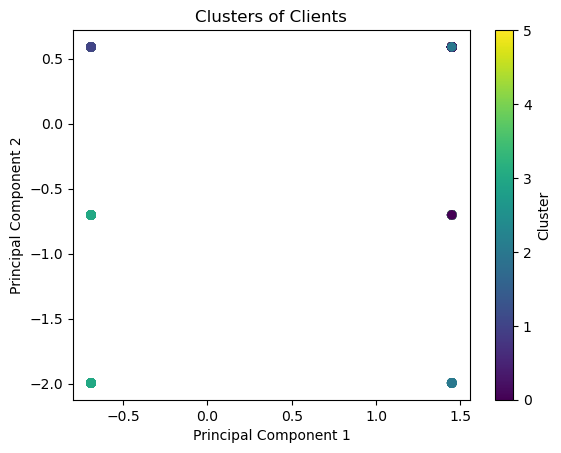

In [39]:
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters of Clients')
plt.colorbar(label='Cluster')
plt.show()

# 12. Группируем по кластерам и анализируем средние значения в каждом кластере

In [32]:
cluster_groups = df.groupby('cluster')

cluster_groups.mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,,,
0,2.000000,2.872340,9247.510638,7378.914894,11326.425532,1350.787234,4691.000000,1427.510638
1,1.000000,3.000000,11941.285000,3060.570000,3497.935000,2950.780000,755.690000,1101.195000
2,2.000000,2.138889,5120.138889,15200.000000,24568.500000,1612.194444,11745.416667,2072.527778
3,1.065934,1.307692,11874.087912,3253.483516,4191.296703,3265.021978,899.285714,1134.461538
4,1.071429,2.785714,44980.428571,13146.785714,11504.000000,19013.142857,1516.000000,8937.642857
5,2.000000,2.800000,25603.000000,43460.600000,61472.200000,2636.000000,29974.200000,2708.800000


# 13. Интерпритация результатов

- Кластер 0 - клиенты с низкими закупками по всем категориям

- Кластер 1 - клиенты с высокими закупками свежих продуктов

- Кластер 2 - клиенты с ориентацией на бытовую химию

- Кластер 3 - клиенты с крупными оптовыми закупками

- Кластер 4 - клиенты со сбалансированным потреблением

- Кластер 5 - клиенты с редкими, но крупными покупками

In [44]:
# Распределение регионов сбыта по кластерам
df['cluster'] = clusters

profession_by_cluster = df.groupby('cluster')['Region'].value_counts(normalize=True).unstack(fill_value=0)
print(profession_by_cluster)

Region          1         2         3
cluster                              
0        0.010638  0.106383  0.882979
1        0.000000  0.000000  1.000000
2        0.333333  0.194444  0.472222
3        0.692308  0.307692  0.000000
4        0.071429  0.071429  0.857143
5        0.000000  0.200000  0.800000


In [43]:
# Распределение каналов сбыта по кластерам
df['cluster'] = clusters

profession_by_cluster = df.groupby('cluster')['Channel'].value_counts(normalize=True).unstack(fill_value=0)
print(profession_by_cluster)

Channel         1         2
cluster                    
0        0.000000  1.000000
1        1.000000  0.000000
2        0.000000  1.000000
3        0.934066  0.065934
4        0.928571  0.071429
5        0.000000  1.000000
